# Projekat: Klasifikacija pecuraka (Edible vs Poisinous)
**Tema**: Nadgledano ucenje - Klasifikacija

**Dataset**: [Mushroom Classification (Kaggle - Biology)](https://www.kaggle.com/datasets/uciml/mushroom-classification)

## Definicija problema i ucitavanje podataka
### Cilj: Na osnovu fizickih karakteristika pecurke predvideti da li je otrovna ili jestiva.

### Ucitavanje biblioteka i skupa podataka.


In [331]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
import time
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [332]:
df = pd.read_csv('data/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Opis atributa 

- <b>class</b>: Klasa (Cilj): edible=e (jestiva), poisonous=p (otrovna)

- <b>cap-shape</b>: Oblik sesira: bell=b (zvonast), conical=c (kupast), convex=x (ispupcen), flat=f (ravan), knobbed=k (kvrgav/izbocen), sunken=s (udubljen)

- <b>cap-surface</b>: Povrsina sesira: fibrous=f (vlaknasta), grooves=g (zljebovita), scaly=y (ljuspasta), smooth=s (glatka)

- <b>cap-color</b>: Boja sesira: brown=n (braon), buff=b (bez/zutosmedja), cinnamon=c (cimet), gray=g (siva), green=r (zelena), pink=p (roze), purple=u (ljubicasta), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>bruises</b>: Uboji (modrice/ostecenja): bruises=t (ima), no=f (nema)

- <b>odor</b>: Miris: almond=a (badem), anise=l (anis), creosote=c (kreozot/dim), fishy=y (riba), foul=f (uzasan/trulez), musty=m (budjav), none=n (bez mirisa), pungent=p (ostar/ljut), spicy=s (zacinski)

- <b>gill-attachment</b>: Prianjanje listica (za drsku): attached=a (pripojeni), descending=d (silazni), free=f (slobodni), notched=n (nazubljeni)

- <b>gill-spacing</b>: Razmak listica: close=c (blizu), crowded=w (zbijeni), distant=d (razmaknuti)

- <b>gill-size</b>: Velicina listica: broad=b (siroki), narrow=n (uski)

- <b>gill-color</b>: Boja listica: black=k (crna), brown=n (braon), buff=b (bez), chocolate=h (cokoladna), gray=g (siva), green=r (zelena), orange=o (narandzasta), pink=p (roze), purple=u (ljubicasta), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>stalk-shape</b>: Oblik drske: enlarging=e (prosiruje se), tapering=t (suzava se)

- <b>stalk-root</b>: Koren drske: bulbous=b (lukovicast), club=c (batinast), cup=u (casast), equal=e (jednak), rhizomorphs=z (rizomorfi/koncici), rooted=r (ukorenjen), missing=? (nepoznato/nedostaje)

- <b>stalk-surface-above-ring</b>: Povrsina drske iznad prstena: fibrous=f (vlaknasta), scaly=y (ljuspasta), silky=k (svilenkasta), smooth=s (glatka)

- <b>stalk-surface-below-ring</b>: Povrsina drske ispod prstena: fibrous=f (vlaknasta), scaly=y (ljuspasta), silky=k (svilenkasta), smooth=s (glatka)

- <b>stalk-color-above-ring</b>: Boja drske iznad prstena: brown=n (braon), buff=b (bez), cinnamon=c (cimet), gray=g (siva), orange=o (narandzasta), pink=p (roze), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>stalk-color-below-ring</b>: Boja drske ispod prstena: (iste boje kao iznad)

- <b>veil-type</b>: Tip vela: partial=p (delimican), universal=u (univerzalan)

- <b>veil-color</b>: Boja vela: brown=n (braon), orange=o (narandzasta), white=w (bela), yellow=y (zuta)

- <b>ring-number</b>: Broj prstenova: none=n (nema), one=o (jedan), two=t (dva)

- <b>ring-type</b>: Tip prstena: cobwebby=c (paucinast), evanescent=e (nestalan/prolazan), flaring=f (siri se/levkast), large=l (veliki), none=n (nema), pendant=p (viseci), sheathing=s (obavijen), zone=z (zona)

- <b>spore-print-color</b>: Boja spora (otisak): black=k (crna), brown=n (braon), buff=b (bez), chocolate=h (cokoladna), green=r (zelena), orange=o (narandzasta), purple=u (ljubicasta), white=w (bela), yellow=y (zuta)

- <b>population</b>: Populacija (kako rastu): abundant=a (izobilna), clustered=c (grupisana/klasteri), numerous=n (brojna), scattered=s (rastrkana), several=v (nekoliko), solitary=y (usamljena)

- <b>habitat</b>: Staniste: grasses=g (trava), leaves=l (lisce), meadows=m (livade), paths=p (staze), urban=u (urbano), waste=w (otpad), woods=d (suma)

## Deskriptivna analiza i priprema podataka

### Tipovi podataka

In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

### Provera nedostatka i duplikata

In [334]:
null_counts = df.isnull().sum()
total_null = null_counts.sum()
print(f"Broj nedostajucih vrednosti u celom datasetu: {total_null}")

dupes = df.duplicated().sum()
print(f"Pronadjeno {dupes} duplikata")

Broj nedostajucih vrednosti u celom datasetu: 0
Pronadjeno 0 duplikata


### Detaljan prikaz atributa u odnosu na klasu (da li je jestiva ili ne)

#### Balans klasa

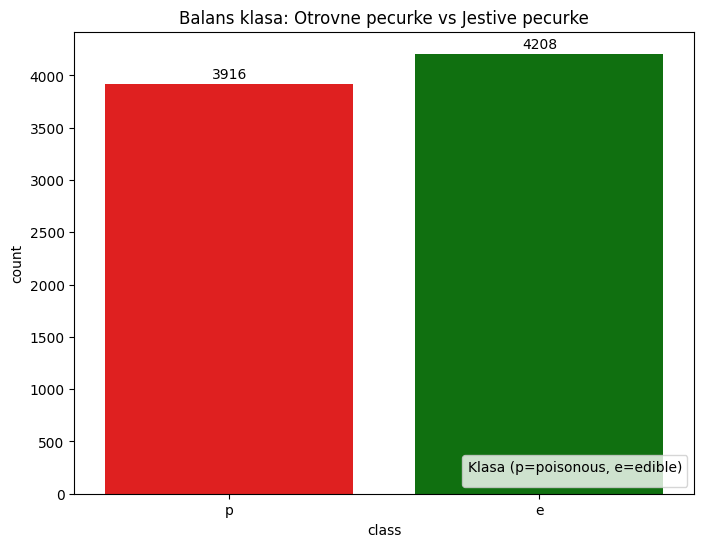

In [335]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    x='class', 
    data=df, 
    hue='class',
    legend=False,
    palette=['red', 'green'] 
)

plt.title('Balans klasa: Otrovne pecurke vs Jestive pecurke')
plt.legend(title='Klasa (p=poisonous, e=edible)', loc='lower right')

for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.show()


#### Distribucija razlicitih cap atributa

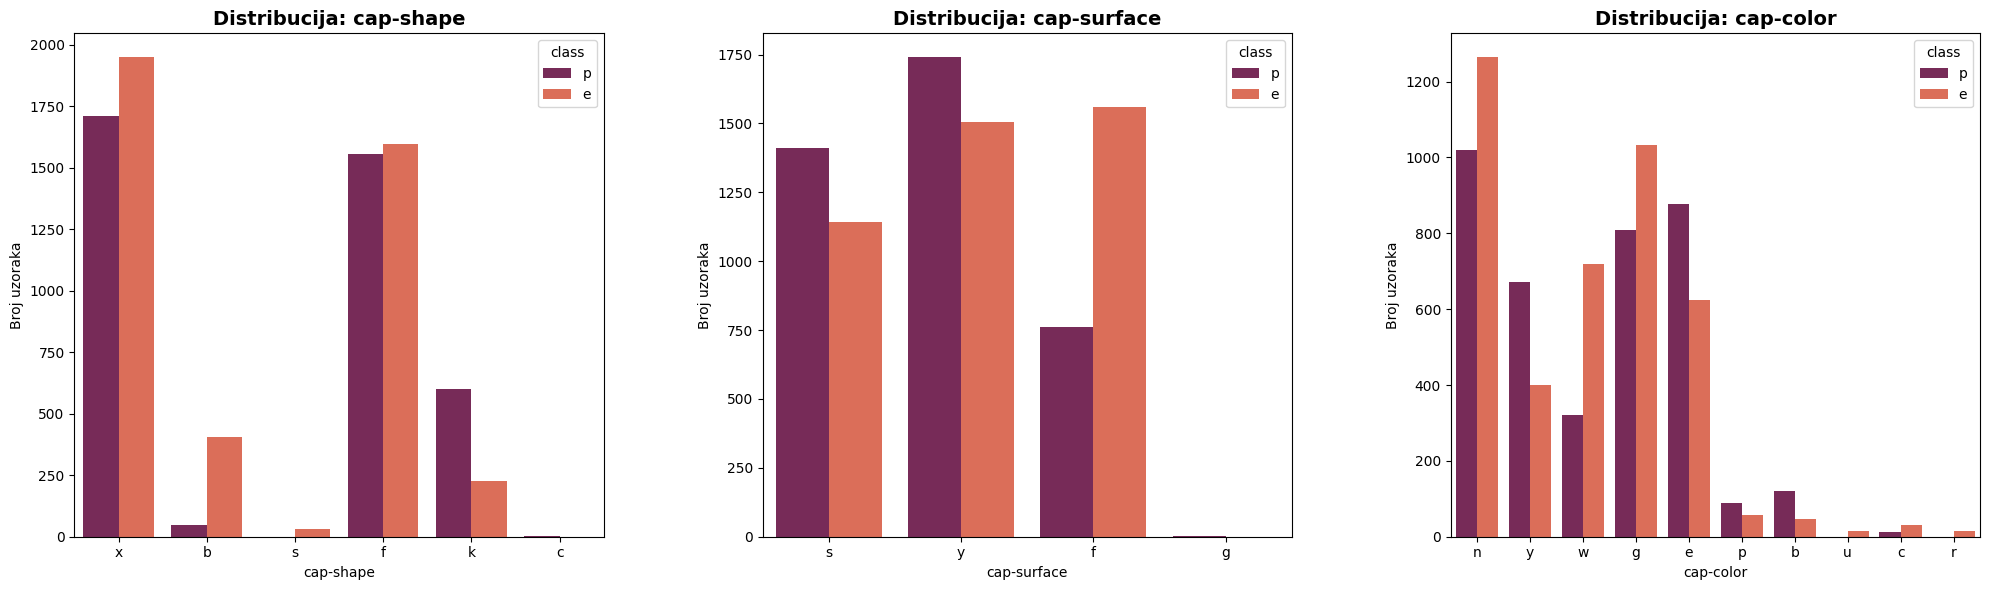

In [336]:
features = ['cap-shape', 'cap-surface', 'cap-color']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(features):
    sns.countplot(x=col, hue='class', data=df, palette="rocket", ax=axes[i])
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

#### Distribucija bruises

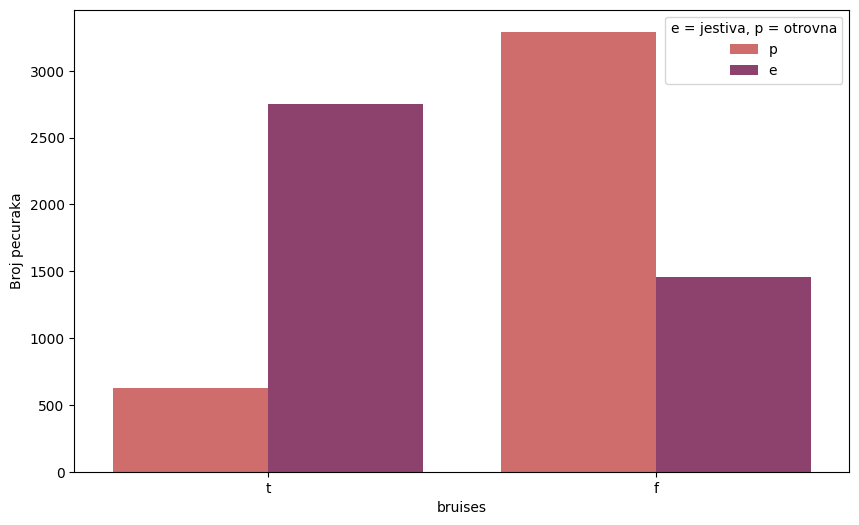

In [337]:
plt.figure(figsize=(10, 6))

sns.countplot(x='bruises', hue='class', data=df, palette='flare')

plt.ylabel('Broj pecuraka')
plt.legend(title='e = jestiva, p = otrovna', loc='upper right')

plt.show()

#### Distribucija odora

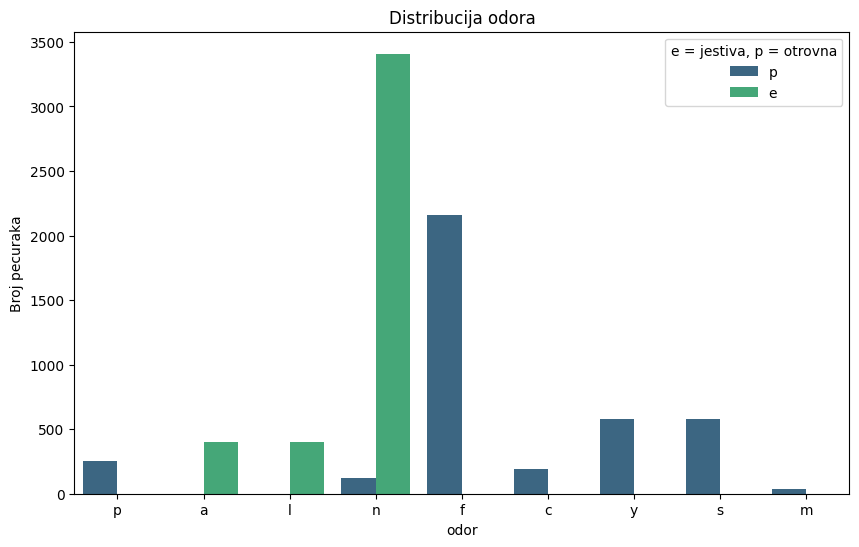

In [338]:
plt.figure(figsize=(10, 6))

sns.countplot(x='odor', hue='class', data=df, palette='viridis')

plt.title('Distribucija odora')
plt.ylabel('Broj pecuraka')
plt.legend(title='e = jestiva, p = otrovna', loc='upper right')


plt.show()

#### Distribucija gill atributa

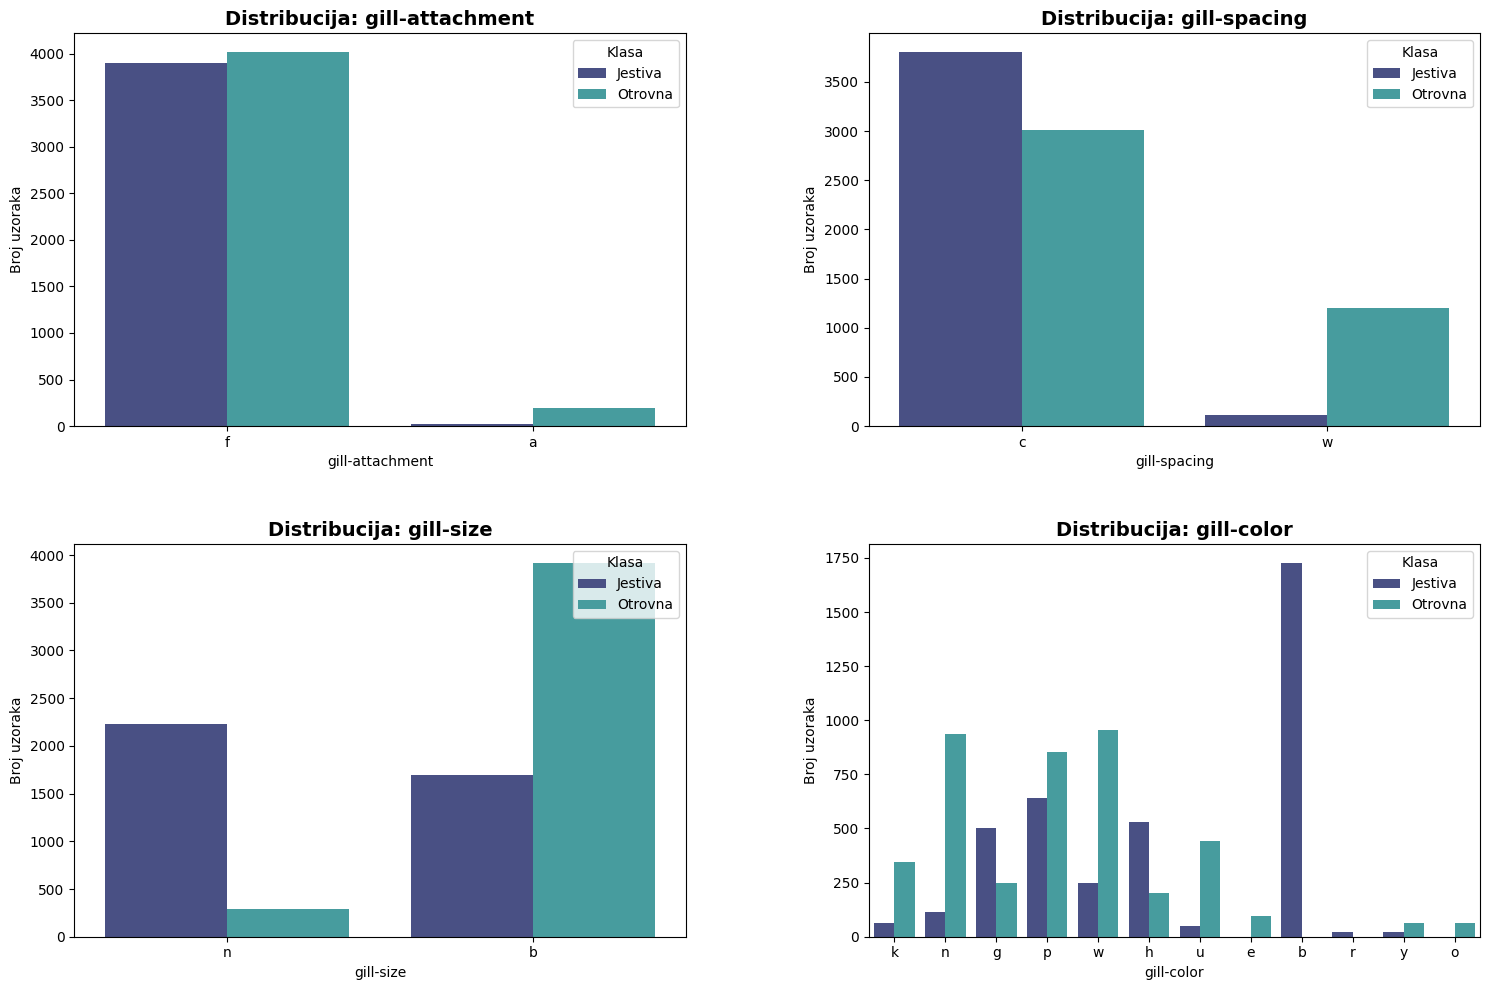

In [339]:
features = ['gill-attachment', 'gill-spacing', 'gill-size', 'gill-color']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

axes = axes.flatten() 

for i, col in enumerate(features):
    sns.countplot(x=col, hue='class', data=df, palette='mako', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')


plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

#### Distribucija korena (stalk)

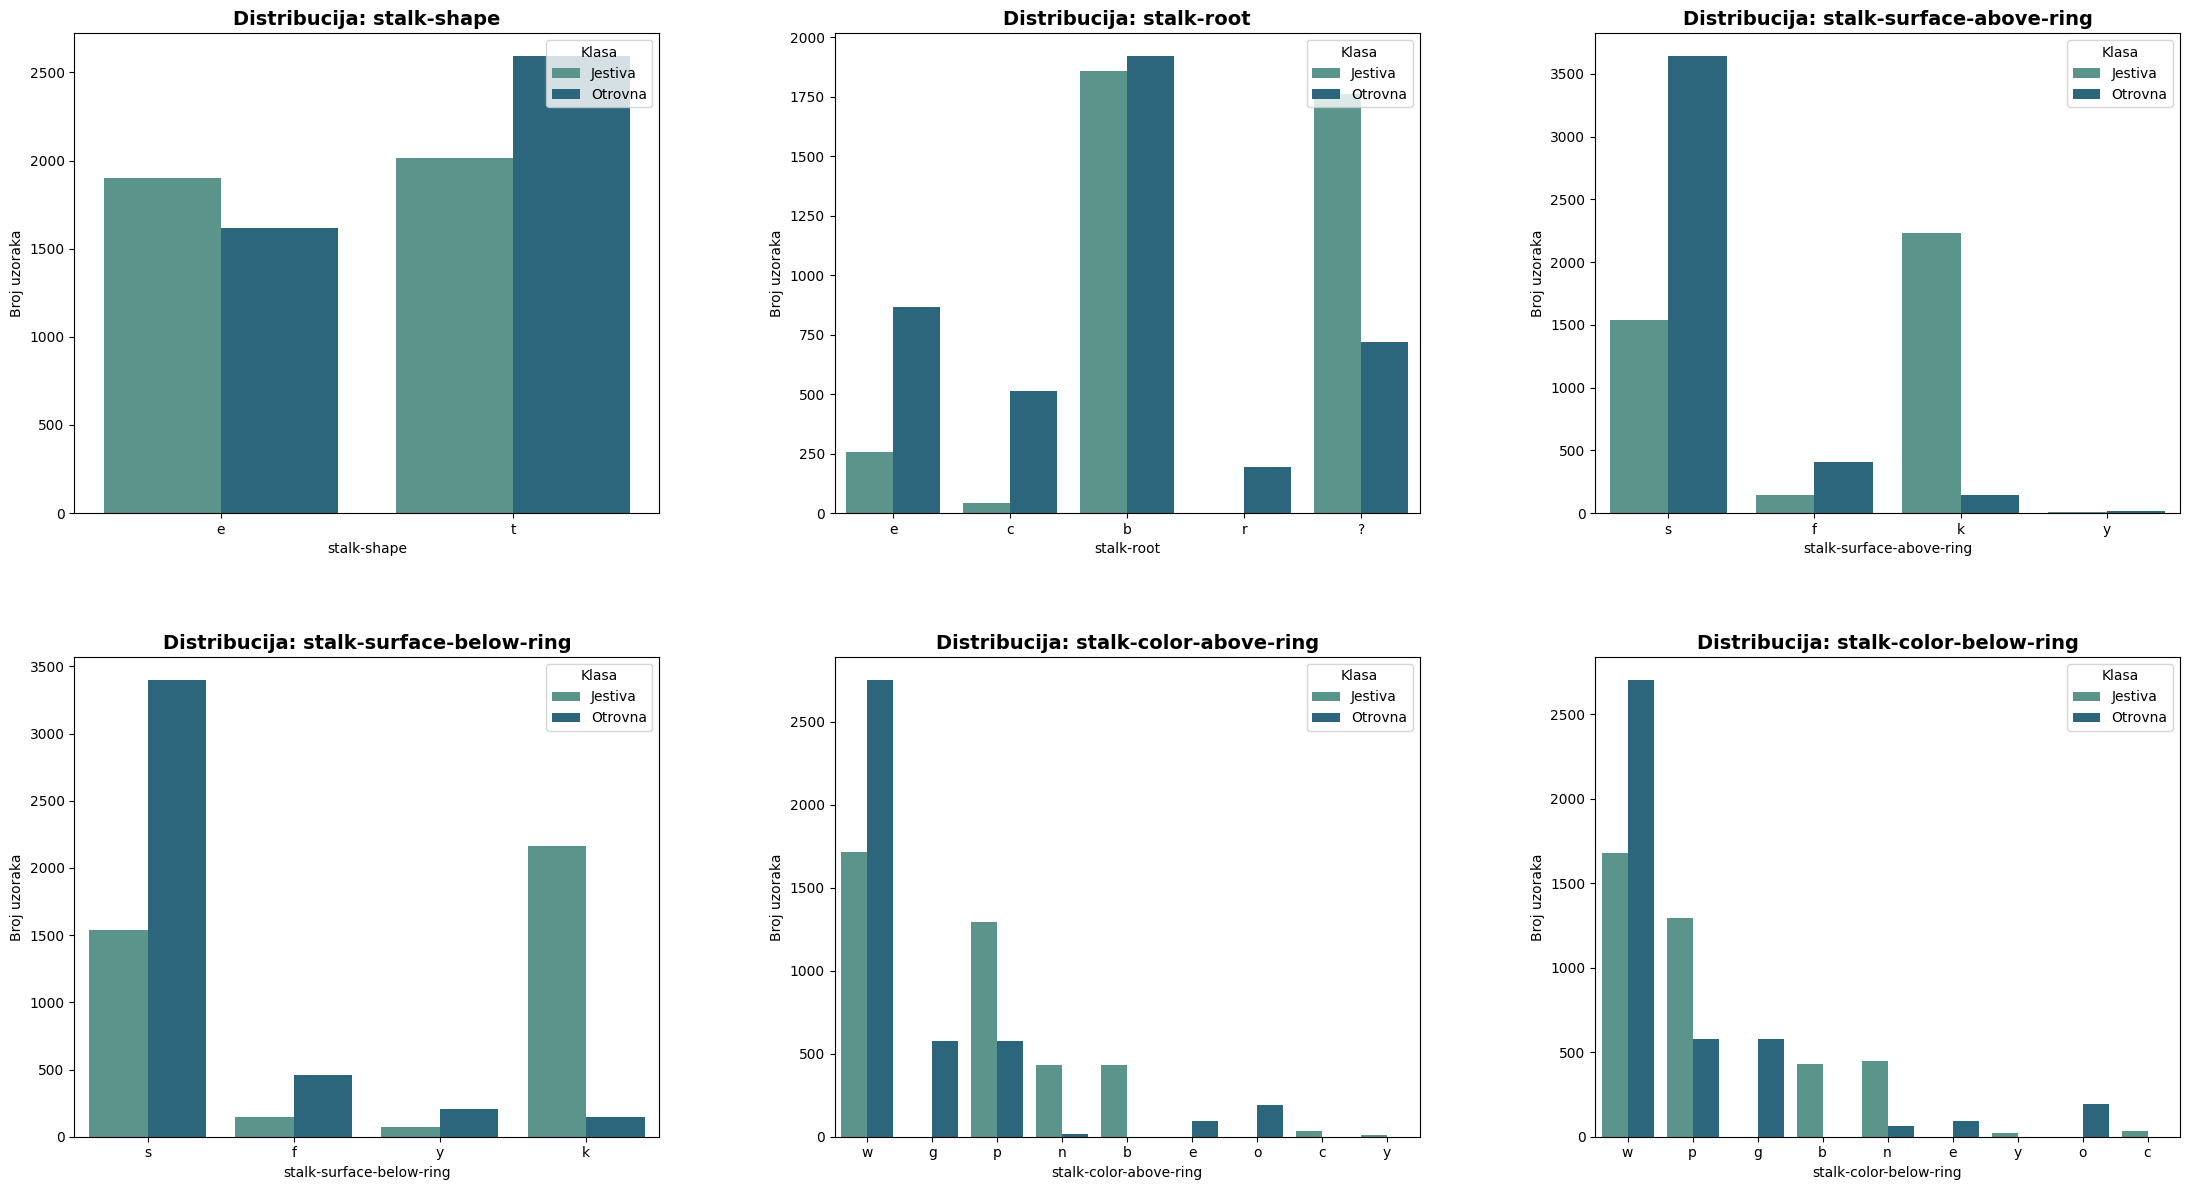

In [340]:
stalk_features = ['stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(22, 12))

axes = axes.flatten() 

for i, col in enumerate(stalk_features):
    sns.countplot(x=col, hue='class', data=df, palette='crest', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

#### Detaljan prikaz samo distribucije vrste korena

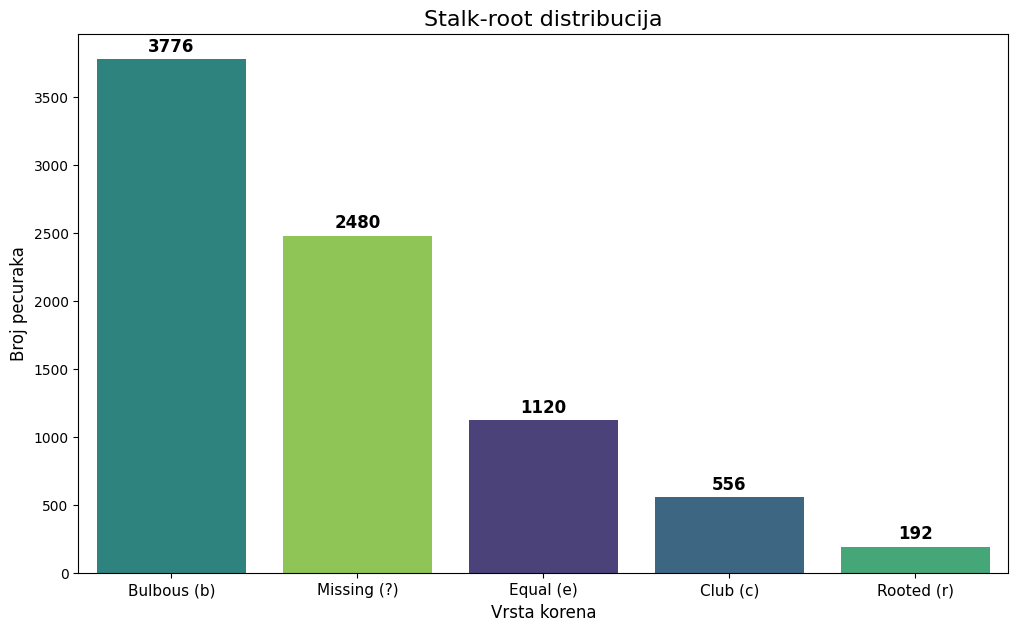

In [341]:
plt.figure(figsize=(12, 7))

df_viz = df.copy()

mapping = {
    'b': 'Bulbous (b)',
    '?': 'Missing (?)',
    'e': 'Equal (e)',
    'c': 'Club (c)',
    'r': 'Rooted (r)'
}

df_viz['stalk-root'] = df_viz['stalk-root'].map(mapping)

ax = sns.countplot(
    x='stalk-root', 
    data=df_viz, 
    hue='stalk-root',
    legend=False,
    palette='viridis',
    order=df_viz['stalk-root'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3, fontweight='bold')

plt.title('Stalk-root distribucija', fontsize=16)
plt.xlabel('Vrsta korena', fontsize=12)
plt.ylabel('Broj pecuraka', fontsize=12)
plt.xticks(fontsize=11)

plt.show()

### Zamena ? u "Unknown" radi tehnicke ispravnosti (One-Hot Encoding) i bolje interpretacije modela

In [342]:
df['stalk-root'] = df['stalk-root'].replace('?', 'Unknown')

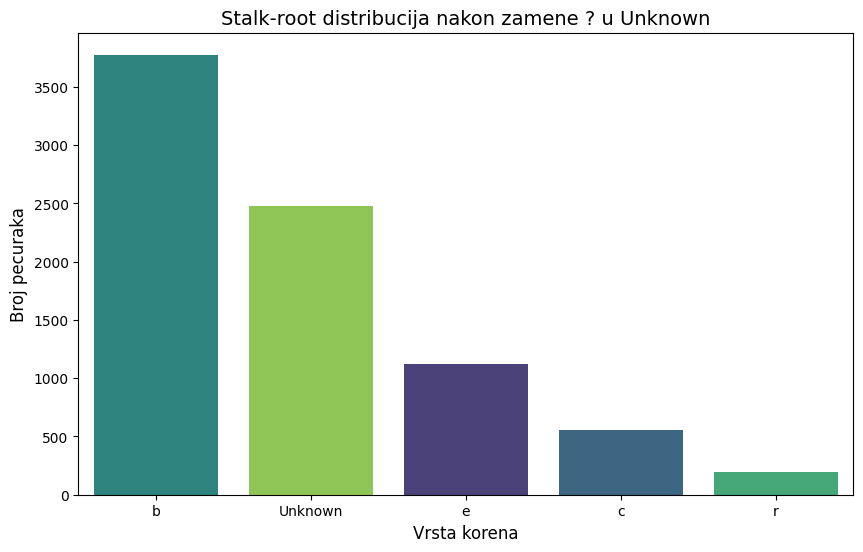

In [343]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    x='stalk-root',
    data=df,
    hue='stalk-root',
    legend=False,
    palette='viridis',
    order=df['stalk-root'].value_counts().index
)

plt.title('Stalk-root distribucija nakon zamene ? u Unknown', fontsize=14)
plt.xlabel('Vrsta korena', fontsize=12)
plt.ylabel('Broj pecuraka', fontsize=12)

plt.show()

#### Distribucija vela

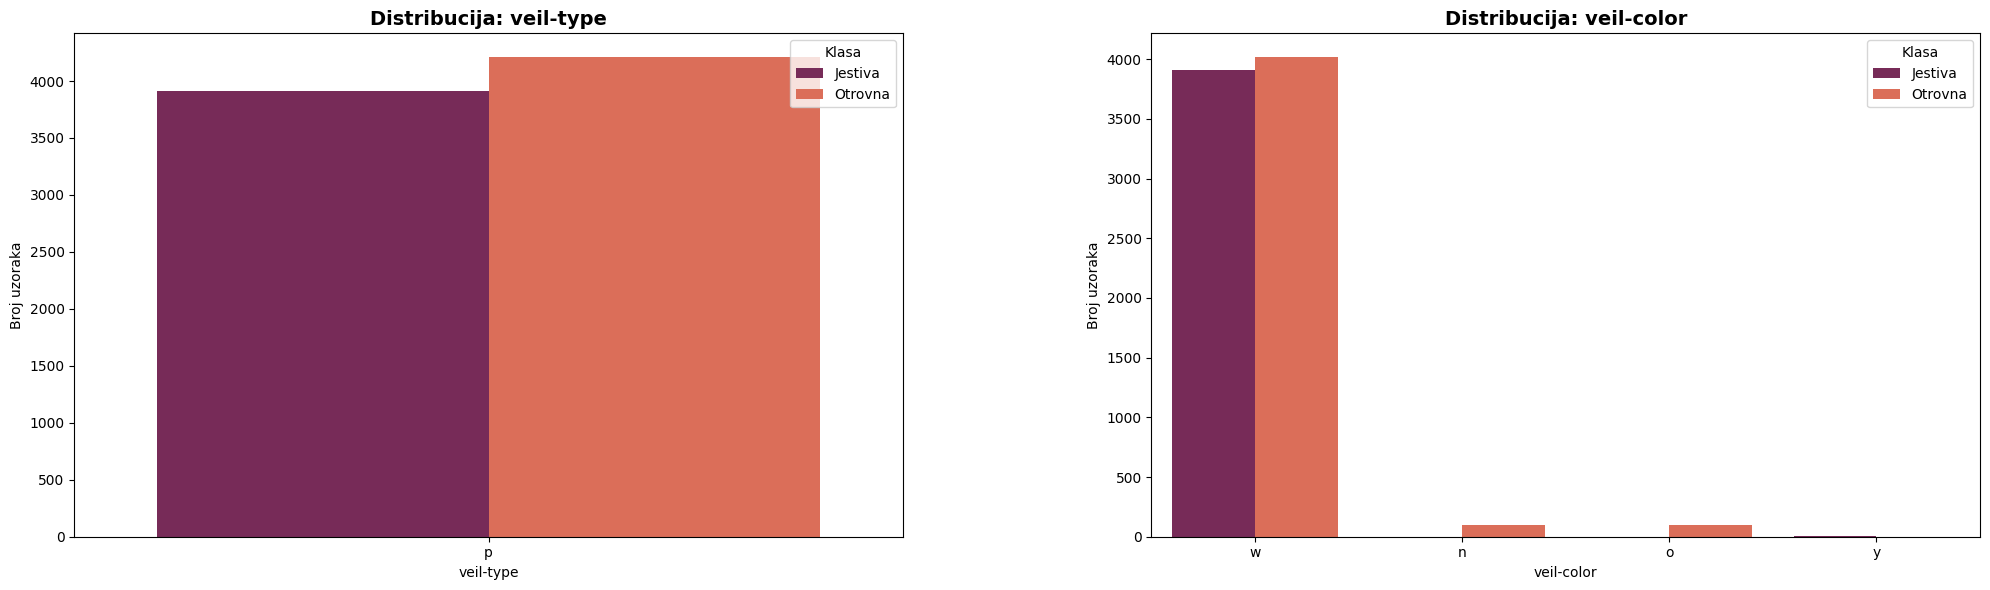

In [344]:
veil_features = ['veil-type', 'veil-color']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

axes = axes.flatten() 

for i, col in enumerate(veil_features):
    sns.countplot(x=col, hue='class', data=df, palette='rocket', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

#### Distribucija prstenova

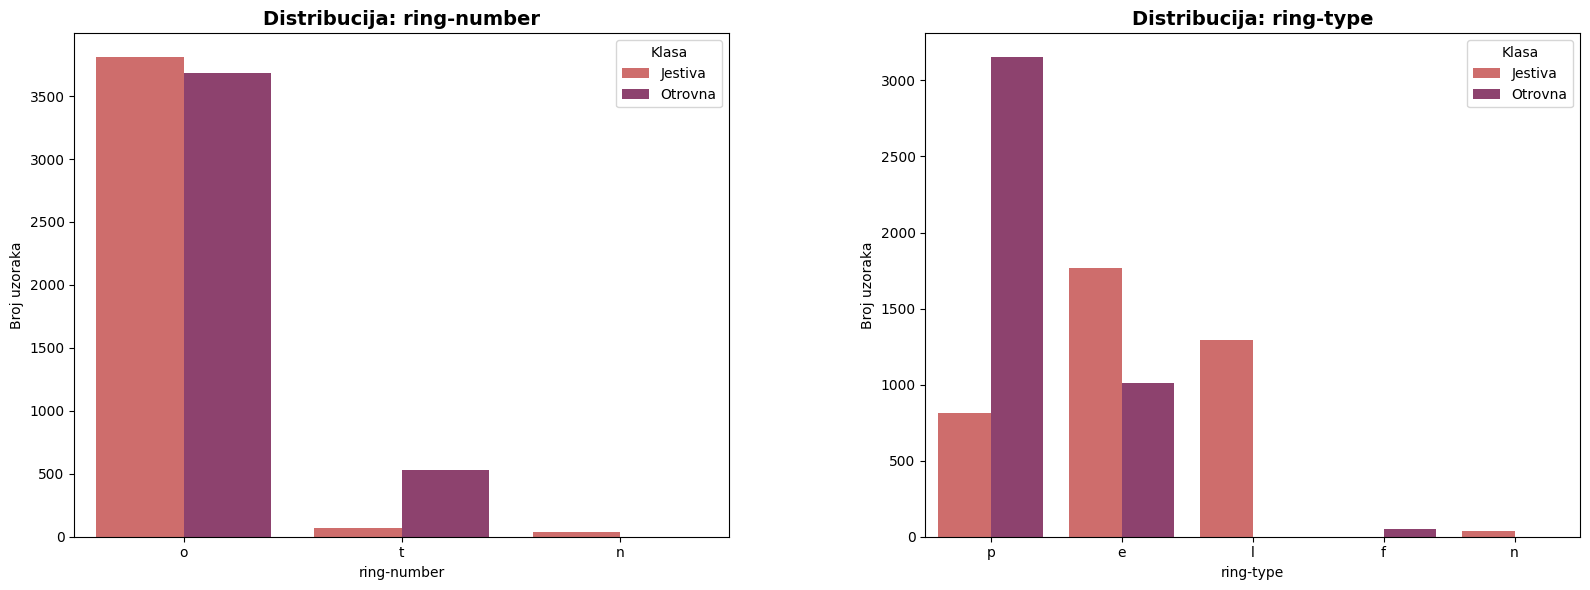

In [345]:
ring_features = ['ring-number', 'ring-type']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(ring_features):
    sns.countplot(x=col, hue='class', data=df, palette='flare', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

#### Distribucija ostalih atributa

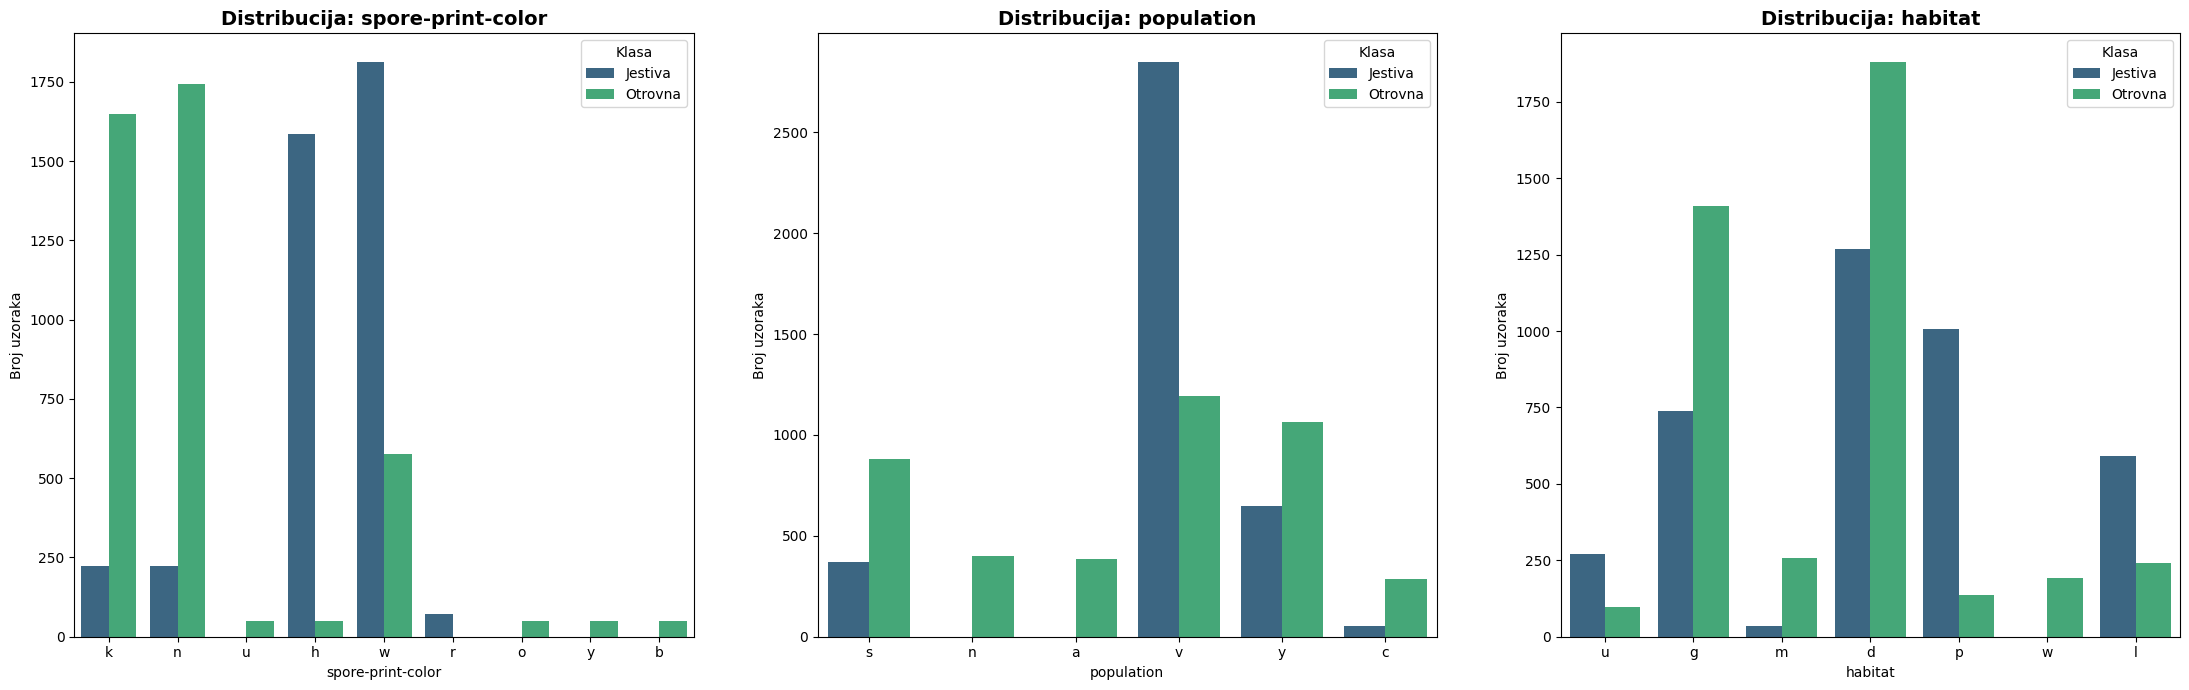

In [346]:
misc_features = ['spore-print-color', 'population', 'habitat']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
axes = axes.flatten()

for i, col in enumerate(misc_features):
    sns.countplot(x=col, hue='class', data=df, palette='viridis', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

### Promene tipova podataka u integer radi prikaza heatmape

In [347]:
df_copy = df.copy()
encoding = LabelEncoder

le = LabelEncoder()

for col in df_copy.columns:
    df_copy[col] = le.fit_transform(df_copy[col])

df_copy.info()
df_copy.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   int64
 1   cap-shape                 8124 non-null   int64
 2   cap-surface               8124 non-null   int64
 3   cap-color                 8124 non-null   int64
 4   bruises                   8124 non-null   int64
 5   odor                      8124 non-null   int64
 6   gill-attachment           8124 non-null   int64
 7   gill-spacing              8124 non-null   int64
 8   gill-size                 8124 non-null   int64
 9   gill-color                8124 non-null   int64
 10  stalk-shape               8124 non-null   int64
 11  stalk-root                8124 non-null   int64
 12  stalk-surface-above-ring  8124 non-null   int64
 13  stalk-surface-below-ring  8124 non-null   int64
 14  stalk-color-above-ring    8124 non-null 

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


### Prikaz toplotne mape

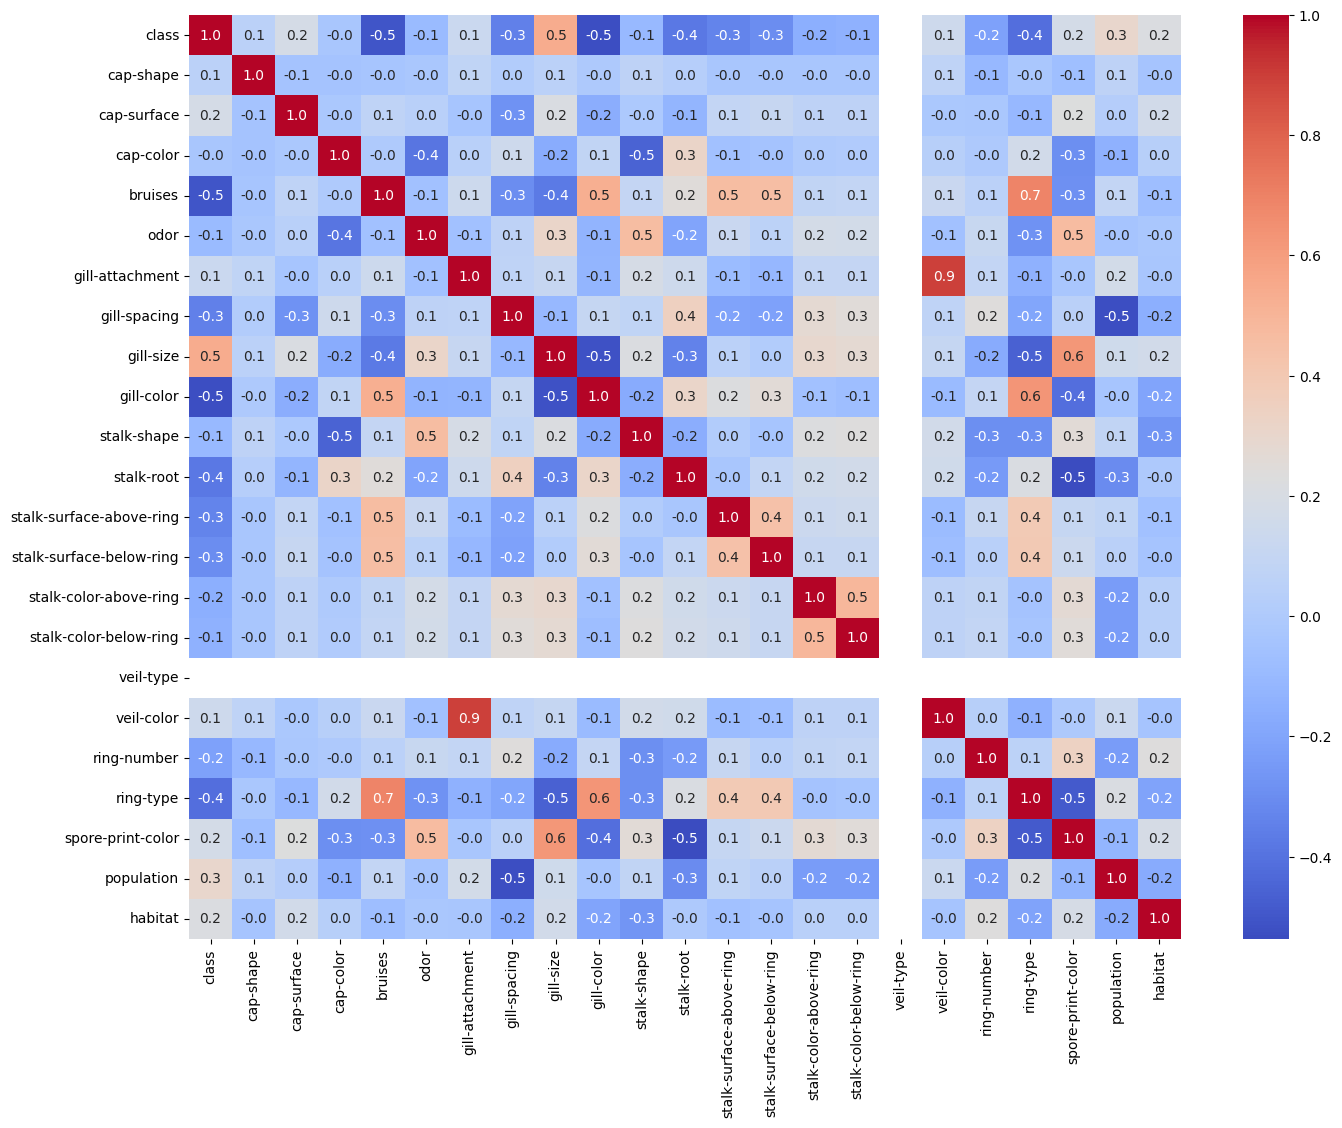

In [348]:
plt.figure(figsize=(16, 12))

sns.heatmap(df_copy.corr(), annot=True, fmt='.1f', cmap='coolwarm')

plt.show()

Graficki prikaz jasno pokazuje da atribut veil-type (tip vela) poseduje nultu varijansu. Svih 8124 uzoraka u skupu podataka imaju identicnu vrednost ('p' - partial). Ovo nece uticati na krajnji cilj modela, zato mozemo da ga uklonimo

### Prikaz topoltne mape bez veil-type atributa

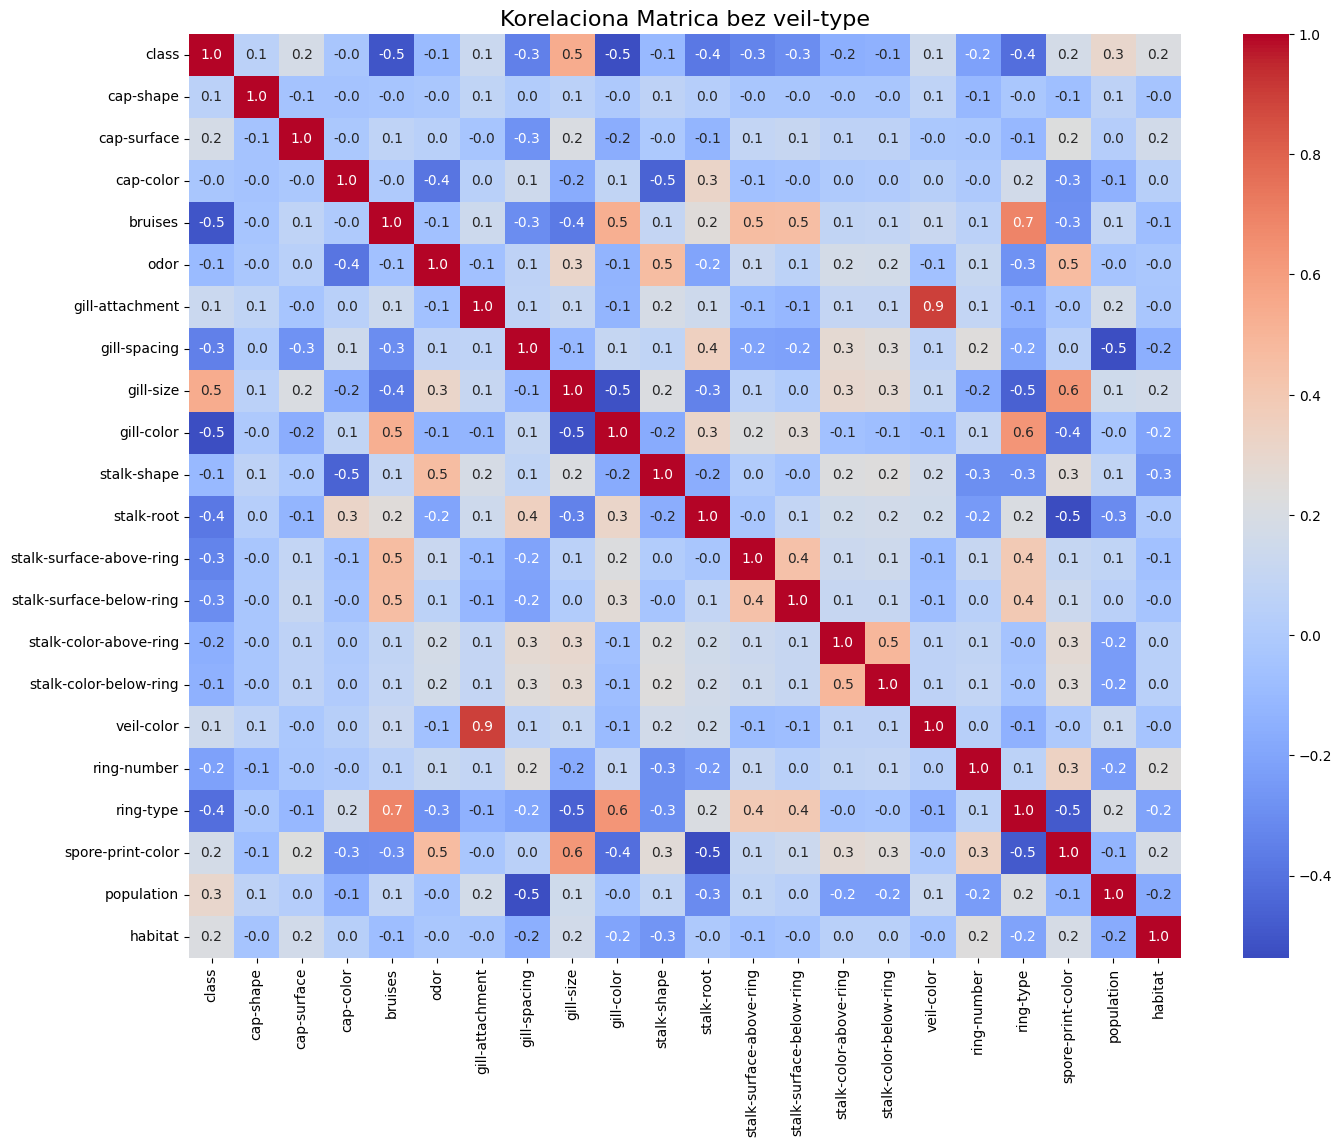

In [349]:
df_copy = df_copy.drop('veil-type', axis=1)

plt.figure(figsize=(16, 12))
sns.heatmap(df_copy.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Korelaciona Matrica bez veil-type', fontsize=16)

plt.show()

### Prikaz atributa koji najvise odaju otrovnu pecurku

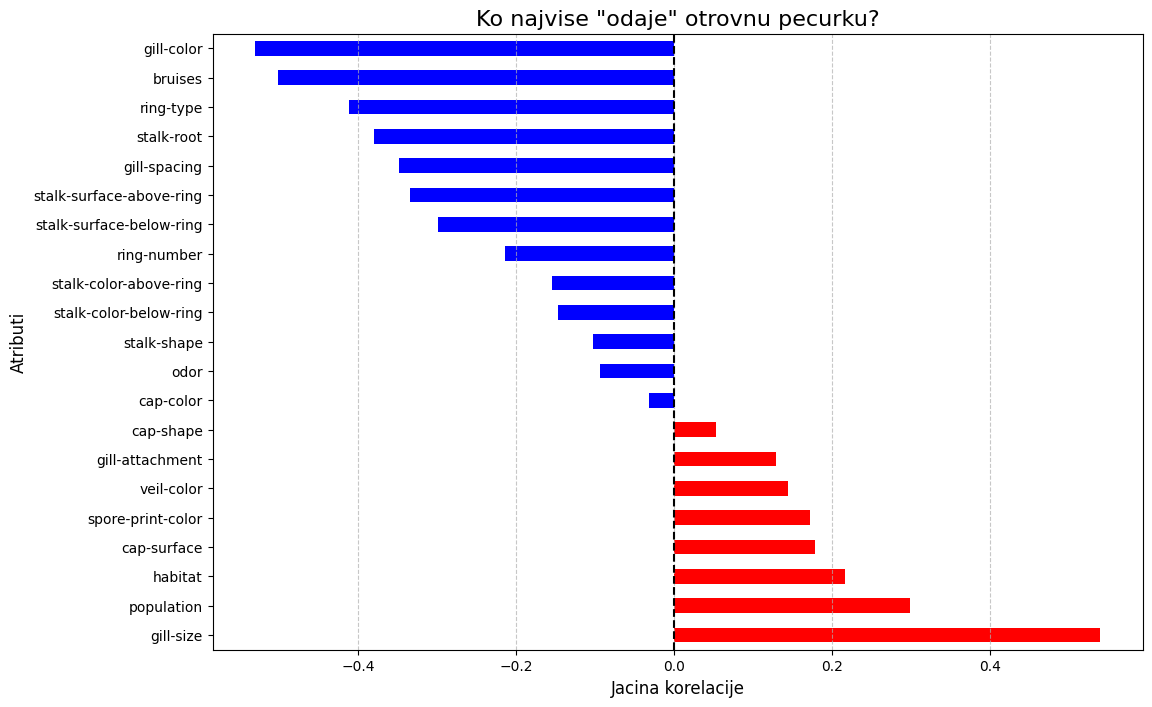

In [350]:
target_corr = df_copy.corr()['class'].sort_values(ascending=False)

target_corr = target_corr.drop('class')

plt.figure(figsize=(12, 8))
target_corr.plot(kind='barh', color=target_corr.apply(lambda x: 'red' if x > 0 else 'blue'))

plt.title('Ko najvise "odaje" otrovnu pecurku?', fontsize=16)
plt.xlabel('Jacina korelacije', fontsize=12)
plt.ylabel('Atributi', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)

### Modifikacija originalnog skupa podataka

In [351]:
if 'veil-type' in df.columns:
    df.drop('veil-type', axis=1, inplace=True) 
    print("Obrisan 'veil-type' iz originala.")

print(f"\nTrenutne dimenzije df-a: {df.shape}")


Obrisan 'veil-type' iz originala.

Trenutne dimenzije df-a: (8124, 22)


### Sistemski pregled

In [352]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,4,9,9,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,s,w,w,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,5176,4936,4464,4384,7924,7488,3968,2388,4040,3148


## Modelovanje Algoritama

### Spremanje podataka za treniranje

In [353]:
print("="*60)
print("Konvertujemo podatke tako da model moze da razume")
print("="*60)

# One-hot Encoding
X = pd.get_dummies(df.drop('class', axis=1), drop_first=True)
y = df['class']

y = y.map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nPodaci za treniranje: {len(X_train):,} (80%)")
print(f"Podaci za testiranje:  {len(X_test):,} (20%)")
print(f"\nBroj kolona: {X.shape[1]}")

print(f"\nRaspodela ciljne promenljive u skupu za treniranje:")
print(f"  Jestive:    {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Otrovne: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

print(f"\nRaspodela ciljne promenljive u skupu za testiranje::")
print(f"  Jestive:    {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Otrovne: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")


Konvertujemo podatke tako da model moze da razume

Podaci za treniranje: 6,499 (80%)
Podaci za testiranje:  1,625 (20%)

Broj kolona: 95

Raspodela ciljne promenljive u skupu za treniranje:
  Jestive:    3366 (51.8%)
  Otrovne: 3133 (48.2%)

Raspodela ciljne promenljive u skupu za testiranje::
  Jestive:    842 (51.8%)
  Otrovne: 783 (48.2%)


### Algoritmi za treniranje

In [354]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}


print("Algoritmi:")


for i, name in enumerate(models.keys(), 1):
    print(f" {i}.{name}")


Algoritmi:
 1.Logistic Regression
 2.Random Forest
 3.Support Vector Machine
 4.K-Nearest Neighbors


In [355]:
results = []

print(f"{'MODEL':<25} | {'ACCURACY':<10} | {'RECALL':<15} | {'CV MEAN':<10}")
print("-"*80)

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None


    # Izrucavanje metrika
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    # Cross-Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Cross-Val (Mean)': cv_scores.mean()
    })

    print(f"{name:<25} | {acc:.2%}    | {rec:.2%}           | {cv_scores.mean():.2%}")

print("-"*80)

MODEL                     | ACCURACY   | RECALL          | CV MEAN   
--------------------------------------------------------------------------------
Logistic Regression       | 99.88%    | 99.74%           | 99.92%
Random Forest             | 100.00%    | 100.00%           | 99.97%
Support Vector Machine    | 100.00%    | 100.00%           | 99.94%
K-Nearest Neighbors       | 100.00%    | 100.00%           | 99.94%
--------------------------------------------------------------------------------


### Uporedjivanje i pregled dobijenih rezultata

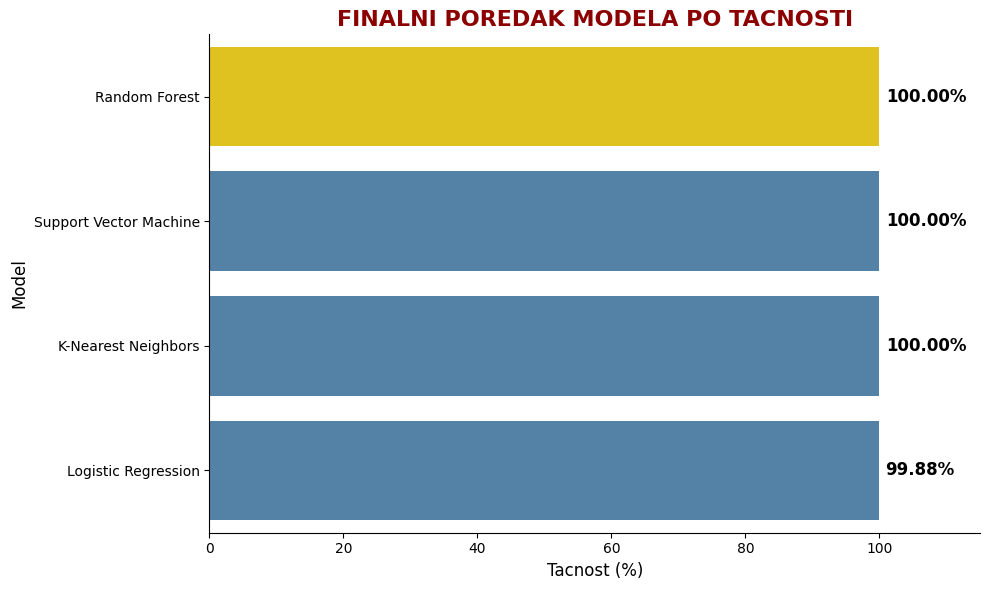

In [356]:
leaderboard_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

leaderboard_df['Accuracy %'] = leaderboard_df['Accuracy'] * 100

colors = ['gold' if i == 0 else 'steelblue' for i in range(len(leaderboard_df))]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Accuracy %', 
    y='Model', 
    data=leaderboard_df, 
    palette=colors
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=5, fontsize=12, fontweight='bold')

plt.title('FINALNI POREDAK MODELA PO TACNOSTI', fontsize=16, fontweight='bold', color='darkred')
plt.xlabel('Tacnost (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)

plt.xlim(0, 115) 

sns.despine()

plt.tight_layout()
plt.show()

In [357]:
display(leaderboard_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Cross-Val (Mean),Accuracy %
1,Random Forest,1.000000,1.0,1.000000,1.000000,1.0,0.999692,100.000000
2,Support Vector Machine,1.000000,1.0,1.000000,1.000000,1.0,0.999385,100.000000
3,K-Nearest Neighbors,1.000000,1.0,1.000000,1.000000,1.0,0.999385,100.000000
0,Logistic Regression,0.998769,1.0,0.997446,0.998721,1.0,0.999231,99.876923


### Optimizacija hiperparametara Random Forest algoritma

In [358]:
rf = models['Random Forest']

parameters = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'criterion': ['gini', 'entropy']
}

print("Pokretanje optimizacije za Random Forest... (Ovo moze potrajati par sekundi)")

grid_rf = GridSearchCV(estimator=rf, param_grid=parameters, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("\nREZULTATI:")
print(f"Najbolja tacnost na treningu: {grid_rf.best_score_:.2%}")
print("Najbolji parametri:")
print(grid_rf.best_params_)

random_forest_best = grid_rf.best_estimator_

Pokretanje optimizacije za Random Forest... (Ovo moze potrajati par sekundi)

REZULTATI:
Najbolja tacnost na treningu: 99.98%
Najbolji parametri:
{'criterion': 'gini', 'max_depth': 20, 'n_estimators': 200}


In [359]:
y_pred_champion = random_forest_best.predict(X_test)

print("="*60)
print(f"KONACNI IZVESTAJ ZA KLASIFIKACIJU")
print("="*60)
print(f"Model: Random Forest Classifier")

print(classification_report(y_test, y_pred_champion, 
                           target_names=['Jestiva (Edible)', 'Otrovna (Poisinous)']))

print("="*60)

KONACNI IZVESTAJ ZA KLASIFIKACIJU
Model: Random Forest Classifier
                     precision    recall  f1-score   support

   Jestiva (Edible)       1.00      1.00      1.00       842
Otrovna (Poisinous)       1.00      1.00      1.00       783

           accuracy                           1.00      1625
          macro avg       1.00      1.00      1.00      1625
       weighted avg       1.00      1.00      1.00      1625



#### Matrica konfuzije

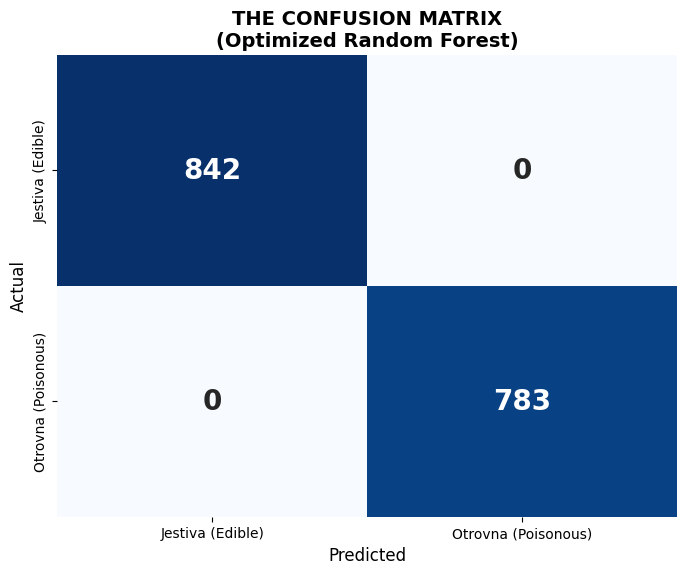

--------------------------------------------------

TUMACENJE KONFUZNE MATRICE:
  True Negatives (Ispravno prepoznate jestive):     842
  True Positives (Ispravno prepoznate otrovne):     783
  False Positives (Jestive oznacene kao otrovne):     0
  False Negatives (Otrovne oznacene kao jestive):     0

False Negatives = 0 <-- OVO JE KRITICAN BROJ
(Lažno negativno znači da OTROVNA pecurka prođe kao bezbedna. Ovakav model ne bi bio prihvatljiv.
--------------------------------------------------


In [360]:
y_pred_champion = random_forest_best.predict(X_test)

cm = confusion_matrix(y_test, y_pred_champion)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Jestiva (Edible)', 'Otrovna (Poisonous)'],
            yticklabels=['Jestiva (Edible)', 'Otrovna (Poisonous)'],
            annot_kws={'size': 20, 'weight': 'bold'}, cbar=False)

plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('THE CONFUSION MATRIX\n(Optimized Random Forest)', fontsize=14, fontweight='bold')

plt.show()

print("-" * 50)
print("\nTUMACENJE KONFUZNE MATRICE:")
print(f"  True Negatives (Ispravno prepoznate jestive):     {cm[0,0]}")
print(f"  True Positives (Ispravno prepoznate otrovne):     {cm[1,1]}")
print(f"  False Positives (Jestive oznacene kao otrovne):     {cm[0,1]}")
print(f"  False Negatives (Otrovne oznacene kao jestive):     {cm[1,0]}")
print(f"\nFalse Negatives = {cm[1,0]} <-- OVO JE KRITICAN BROJ")
print("(Lažno negativno znači da OTROVNA pecurka prođe kao bezbedna. Ovakav model ne bi bio prihvatljiv.")
print("-" * 50)


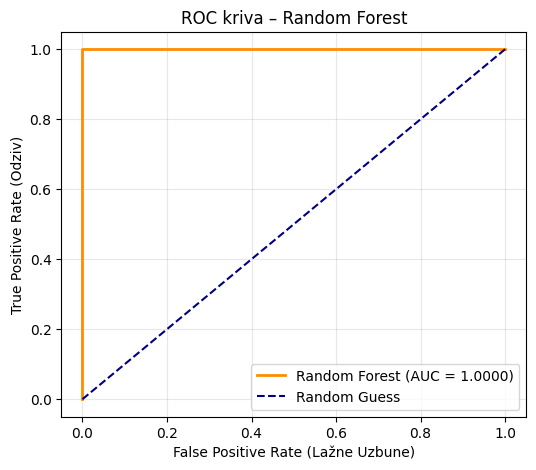

In [ ]:
y_proba = random_forest_best.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f"Random Forest (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate (Lažne Uzbune)")
plt.ylabel("True Positive Rate (Odziv)")
plt.title("ROC kriva - Random Forest")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretabilnost modela

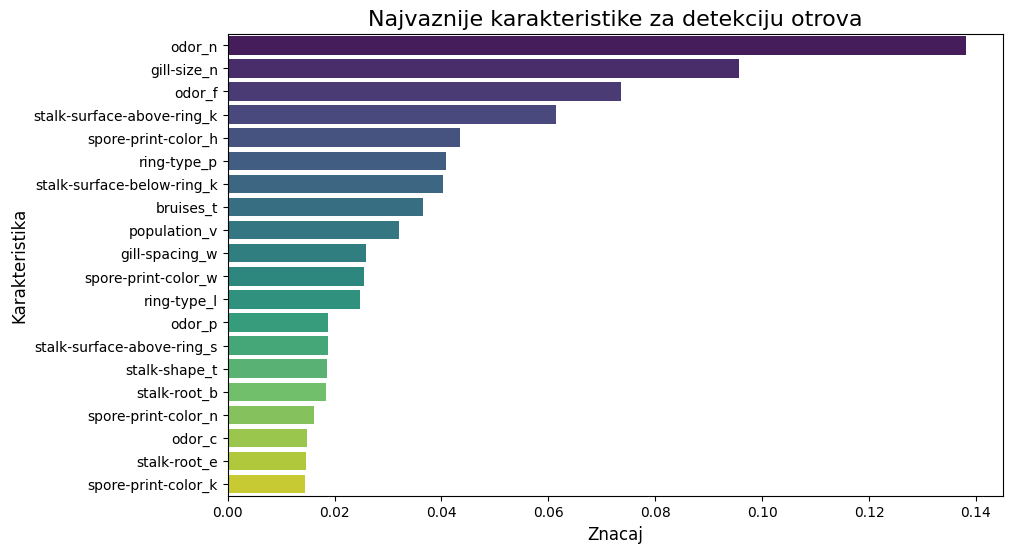

Najbitnija karakteristika je: odor_n


In [362]:
# Random Forest ima ugradjen feature importance
importances = random_forest_best.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')

plt.title('Najvaznije karakteristike za detekciju otrova', fontsize=16)
plt.xlabel('Znacaj', fontsize=12)
plt.ylabel('Karakteristika', fontsize=12)
plt.show()

print("Najbitnija karakteristika je:", feature_importance_df.iloc[0]['Feature'])


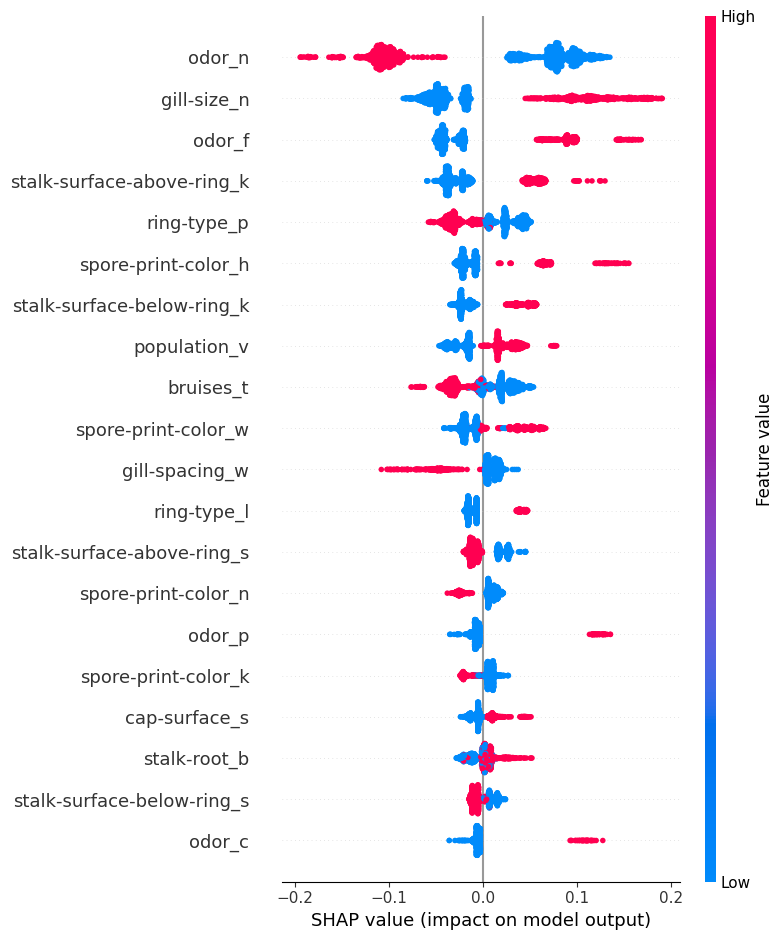

In [363]:
explainer = shap.TreeExplainer(random_forest_best)

shap_values = explainer.shap_values(X_test)

shap_values_poisonous = shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_poisonous, X_test)
plt.show()